# Experiment 2: SAE Feature Decomposition

| | |
|---|---|
| **Author** | Elad Moshe |
| **Mentors** | Prof. Luciano Pezzuti & Prof. [Co-supervisor] |
| **Institution** | IE Madrid — MSc Computer Science |
| **Date** | June 2026 |
| **Priority** | MUST-HAVE (Interpretability layer) |

> ---
> **AI Assistance Disclaimer:** Portions of this notebook (code scaffolding, documentation,
> and structural outlines) were generated with the assistance of Claude (Anthropic). All
> experimental design, interpretation, and conclusions are the author's own. AI-generated
> content has been reviewed and validated by the author before inclusion.
> ---

## Notebook Overview

**Research question:** How much of the correctness-discriminative signal in the residual
stream is *interpretable* (captured by SAE features) vs *diffuse* (lives in the SAE error)?

**Approach:** Every layer-12 activation `x` is split into three non-overlapping parts via
Gemma Scope, and logistic-regression AUROC is measured separately on each:

```
x  =  decode(encode(x))  +  (x − decode(encode(x)))
    reconstructed              error
```

| Partition | Dim | Meaning |
|---|---|---|
| **Raw residual** | 2 304 | Baseline (from Exp 1) |
| **SAE features** | 16 384 | Sparse, human-interpretable activations |
| **Reconstructed** | 2 304 | Dense portion *covered* by the SAE |
| **Error** | 2 304 | Dense portion *not* covered by the SAE |

**Sample:** n = 400 · **no new forward passes** — all activations come from Exp 1 cache.

**Classifier:** L2 logistic regression, C = 0.1, `class_weight='balanced'`, 5-fold CV.

**Primary metric:** AUROC (averaged over folds).

### Persistent outputs (Google Drive → synced to OneDrive)

> Saved to `<this notebook's Drive folder>/backup/` — survives session disconnects.
> Location is auto-detected by §0 — no path to configure.

| Path (relative to `backup/`) | Content | Shape |
|---|---|---|
| `cache/decomp_{cond}_{pos}_features.npy` | Sparse feature activations | (400, 16 384) |
| `cache/decomp_{cond}_{pos}_reconstructed.npy` | SAE reconstruction | (400, 2 304) |
| `cache/decomp_{cond}_{pos}_error.npy` | Residual error | (400, 2 304) |
| `cache/lr_fast_all.csv` | AUROC for raw / reconstructed / error (all combos) | — |
| `cache/lr_features_{cond}_{pos}.csv` | AUROC for features — one file per combo | — |
| `cache/decomp_lr_results.csv` | Final aggregated AUROC table | — |
| `cache/top_features_{cond}_{pos}.csv` | Features ranked by LR coefficient | — |
| `cache/top_features_cot_pos_a_annotated.csv` | Top features + Neuronpedia descriptions | — |
| `cache/neuronpedia_descriptions.json` | API description cache (grows across runs) | — |
| `figures/fig1_decomposition_bar_{pos}.png` | AUROC decomposition bar chart | — |
| `figures/fig2_top_features_cot_pos_a.png` | Top-feature importance chart | — |
| `figures/fig3_feature_distributions.png` | Correct vs incorrect activation box plots | — |

## Installation

**Run once, then restart the session** (`Runtime → Restart session`).

> Exp 2 does **not** load Gemma-2-2B itself — only the much smaller SAE weights (~150 MB).
> No Gemma licence acceptance is required for this notebook.

In [ ]:
# Run this cell once, then Runtime → Restart session.
import subprocess, sys

# Remove Colab's binary-incompatible media libs
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
                'torchvision', 'torchaudio'], capture_output=True)

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'sae-lens>=3.0.0',
    'requests',
    'scikit-learn>=1.3',
    'pyarrow',
    'tqdm',
    'ipywidgets',
], check=True)

print('Packages installed.')
print('>>> Runtime -> Restart session, then run from cell 2. <<<')

Packages installed.
>>> Runtime -> Restart session, then run from cell 2. <<<


## 0. Mount Google Drive

**All outputs are written directly to Google Drive — nothing goes to Colab's
ephemeral local storage.** Session disconnects are safe; pick up exactly where
you left off by re-running the setup cells.

### Zero configuration

Just run the cell — it **auto-detects** the `exp2_sae_decomposition` folder
in your Drive by searching the *Computers* section (where Google Drive for
Desktop syncs your files). No path to type or configure.

Folder layout created automatically:

```
<NOTEBOOK_DIR>/
└── backup/
    ├── cache/       ← .npy · .csv · .json
    └── figures/     ← .png

<NOTEBOOK_DIR>/../exp1_residual_stream_regression/backup/cache/
    ← exp1 activations (exp1 notebook must use the same backup layout)
```

In [ ]:
from google.colab import drive
from pathlib import Path
import subprocess

drive.mount('/content/drive')

# ── Auto-detect the notebook folder ──────────────────────────────────────
# Searches Drive for the 'exp2_sae_decomposition' directory.
# The folder lives under 'Computers' (synced via Google Drive for Desktop).
# No path configuration needed — runs automatically.

def _find_notebook_dir(name: str = 'exp2_sae_decomposition') -> Path:
    """
    Locate the notebook folder in the mounted Drive.
    Strategy 1 (fast): walk one level under MyDrive — catches shortcuts directly.
    Strategy 2 (fallback): find -L to follow symlinks inside Computers.
    """
    my_drive = Path('/content/drive/MyDrive')

    # ── Strategy 1: direct walk of MyDrive (handles shortcuts) ───────────
    if my_drive.exists():
        top = sorted(d for d in my_drive.iterdir() if d.is_dir())
        print(f'  MyDrive entries: {[d.name for d in top]}')
        for entry in top:
            if entry.name == name:                  # shortcut named after notebook
                return entry
            candidate = entry / name               # shortcut to parent (e.g. experiments)
            if candidate.exists():
                return candidate
    else:
        print('  /content/drive/MyDrive not found — check Drive mount.')

    # ── Strategy 2: find -L (follows symlinks; searches Computers too) ───
    roots = ([str(my_drive)] if my_drive.exists() else [])
    computers = Path('/content/drive/Computers')
    if computers.exists():
        roots.append(str(computers))
    for root in roots:
        print(f'  Falling back to find -L in {Path(root).name}...')
        r = subprocess.run(
            ['find', '-L', root, '-maxdepth', '20', '-type', 'd', '-name', name],
            capture_output=True, text=True, timeout=240,
        )
        hits = [p.strip() for p in r.stdout.strip().split('\n')
                if p.strip() and '/backup' not in p and '/.Trash' not in p]
        if hits:
            return Path(hits[0])

    # ── Nothing found — print actionable error ────────────────────────────
    top_names = ([d.name for d in my_drive.iterdir()]
                 if my_drive.exists() else [])
    raise RuntimeError(
        f'Could not find "{name}" in Drive.\n'
        f'  MyDrive contents: {top_names}\n\n'
        'To fix — pick ONE option:\n'
        '  A) Shortcut: drive.google.com → find the "experiments" folder\n'
        '     → Right-click → Organize → Add shortcut → My Drive\n'
        '     Then re-run this cell.\n\n'
        '  B) Manual override — add this line BEFORE the _find_notebook_dir() call:\n'
        f'     NOTEBOOK_DIR = Path("/content/drive/MyDrive/<folder_in_list_above>/{name}")\n'
        '     (use the MyDrive contents list above to find the right parent folder)'
    )


print('Auto-detecting notebook folder in Drive...')
NOTEBOOK_DIR = _find_notebook_dir()

# All exp2 outputs go into backup/ inside the notebook folder
BACKUP_DIR  = NOTEBOOK_DIR / 'backup'
CACHE_DIR   = BACKUP_DIR / 'cache'
FIGURES_DIR = BACKUP_DIR / 'figures'

# Exp1 activations — try canonical path first, fall back to old location
_exp1_new = NOTEBOOK_DIR.parent / 'exp1_residual_stream_regression' / 'backup' / 'cache'
_exp1_old = Path('/content/drive/MyDrive/exp1_cache')
if _exp1_new.exists():
    EXP1_CACHE = _exp1_new
elif _exp1_old.exists():
    print(f'  exp1 cache found at old location: {_exp1_old}')
    print(f'  (Run exp1 migration cell to move to canonical path — optional)')
    EXP1_CACHE = _exp1_old
else:
    EXP1_CACHE = _exp1_new  # will give clear error in §1

CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Drive ready.')
print(f'  Notebook:        {NOTEBOOK_DIR}')
print(f'  Backup/cache:    {CACHE_DIR}')
print(f'  Backup/figures:  {FIGURES_DIR}')
print(f'  Exp1 cache:      {EXP1_CACHE}')
print(f'  Exp1 cache exists: {EXP1_CACHE.exists()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Auto-detecting notebook folder in Drive...
  MyDrive entries: ['Colab Notebooks', 'Elad Moshe - MSc in CS', 'Research Capstone - Elad (LLM Reasoning)', 'University', 'exp1_cache', 'exp1_figures', 'experiments', 'h1_checkpoints', 'h1_runs', 'research capstone', 'אלעד משה - תואר שני', 'אלעד משה - תואר שני (1)', 'דרייב מחו"ג', 'כספות', 'מדמ"ח', 'מדעי המחשב', 'מדעי המחשב ישן ', 'מעבדות עותק', 'מעבדות פיזיקה אלעד משה', 'מערכות הפעלה', 'מערכות הפעלה (1)', 'סרטים להגות צבאית', 'פייתון תיכון', 'רב תחומי', 'שנה שלישית - חבצלות', 'תיק השקעות', 'תיקיית יב - תמונות']
  exp1 cache found at old location: /content/drive/MyDrive/exp1_cache
  (Run exp1 migration cell to move to canonical path — optional)
Drive ready.
  Notebook:        /content/drive/MyDrive/experiments/exp2_sae_decomposition
  Backup/cache:    /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/

## 0b. Setup & Imports

Run on every session after mounting Drive. Imports libraries and sets all constants.
`CACHE_DIR` and `FIGURES_DIR` are already defined by the Drive cell above.

In [ ]:
import sys, importlib.util, os, json, warnings, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import torch
import requests
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Neutralise Colab's binary-incompatible torchaudio/torchvision before
# importing anything that triggers transformers' is_X_available() checks.
def _neutralise(pkg):
    try:
        __import__(pkg)
    except (OSError, ImportError):
        for key in list(sys.modules.keys()):
            if key == pkg or key.startswith(pkg + '.'):
                del sys.modules[key]
        _orig = importlib.util.find_spec
        def _patched(name, *a, **kw):
            if name == pkg or name.startswith(pkg + '.'):
                return None
            return _orig(name, *a, **kw)
        importlib.util.find_spec = _patched

_neutralise('torchaudio')
_neutralise('torchvision')
warnings.filterwarnings('ignore')

# ── Constants ─────────────────────────────────────────────────────────────
SEED       = 42
SAE_LAYER  = 12
HIDDEN_DIM = 2304
N_FEATURES = 16384
POSITIONS  = ['pos_a', 'pos_b']   # pos_a = last pre-answer token; pos_b = last prompt token
LR_C       = 0.1
LR_FOLDS   = 5
BATCH_SIZE = 64                   # samples per SAE forward pass

# Gemma Scope canonical SAE — layer 12, 16k features, residual stream
SAE_RELEASE = 'gemma-scope-2b-pt-res-canonical'
SAE_ID      = f'layer_{SAE_LAYER}/width_16k/canonical'

# Neuronpedia identifiers
NP_MODEL = 'gemma-2-2b'
NP_LAYER = f'{SAE_LAYER}-gemmascope-res-16k'
NP_BASE  = 'https://www.neuronpedia.org/api'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# CACHE_DIR, FIGURES_DIR, BACKUP_DIR, and EXP1_CACHE are set by the Drive
# mount cell (§0). Verify they exist and point to Drive before continuing.
for _name, _path in [('CACHE_DIR',   CACHE_DIR),
                     ('FIGURES_DIR', FIGURES_DIR),
                     ('EXP1_CACHE',  EXP1_CACHE)]:
    assert '/content/drive/' in str(_path), (
        f'{_name} does not point to Google Drive: {_path}\n'
        'Run the Drive mount cell (§0) before this cell.'
    )

np.random.seed(SEED)
torch.manual_seed(SEED)
print('Setup complete.')
print(f'  Backup root: {BACKUP_DIR}')

Device: cuda
Setup complete.
  Backup root: /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup


## 0c. API Keys

Neuronpedia requires an API key for feature lookups. Obtain one at
[neuronpedia.org/api-key](https://www.neuronpedia.org/api-key).

In Colab: add `NEURONPEDIA_API_KEY` to Secrets (🔑 icon, left sidebar).

In [ ]:
try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def get_secret(name: str) -> str:
    if IN_COLAB:
        try:
            v = userdata.get(name)
            if v:
                return v.strip()
        except Exception:
            pass
    v = os.environ.get(name, '')
    if not v:
        v = getpass.getpass(f'{name}: ')
    return v.strip()


NEURONPEDIA_API_KEY = get_secret('NEURONPEDIA_API_KEY')

# Quick connectivity check — prints feature 0 description if key is valid
test_url = f'{NP_BASE}/feature/{NP_MODEL}/{NP_LAYER}/0'
resp = requests.get(test_url, headers={'x-api-key': NEURONPEDIA_API_KEY}, timeout=10)
if resp.ok:
    exps = resp.json().get('explanations', [])
    desc = exps[0]['description'] if exps else '<no description>'
    print(f'Neuronpedia OK — feature 0: {desc}')
else:
    print(f'WARNING: Neuronpedia check failed ({resp.status_code}). '
          f'Feature lookups will be skipped.')

Neuronpedia OK — feature 0:  references to labeled data or metadata in documents


## Quick Reload (new session shortcut)

**Run this cell instead of §1–§5 when all cache files already exist on Drive.**
Requires: §0 (Drive mount) and §0b (Setup) already run.

Loads: labels, raw activations, decompositions, LR results, and top features — all from Drive cache.
Then jump straight to §6–§8 to re-plot or inspect.

In [ ]:
# ── Fast reload — skip §1–§5 if all caches are present ─────────────────
_quick_ok = True

# Labels + raw activations (from Exp 1 cache)
if EXP1_CACHE.exists():
    df_cot   = pd.read_parquet(EXP1_CACHE / 'responses_cot.parquet')
    df_nocot = pd.read_parquet(EXP1_CACHE / 'responses_nocot.parquet')
    y_cot    = df_cot['correct'].astype(int).values
    y_nocot  = df_nocot['correct'].astype(int).values
    raw_acts = {}
    for _c in ('cot', 'nocot'):
        for _p in POSITIONS:
            _f = EXP1_CACHE / f'acts_{_c}_{_p}_layer{SAE_LAYER}.npy'
            if _f.exists():
                raw_acts[(_c, _p)] = np.load(_f)
            else:
                print(f'  MISSING: {_f.name}')
                _quick_ok = False
    print(f'  Labels + activations loaded  (CoT acc={y_cot.mean():.1%})')
else:
    print(f'  EXP1_CACHE not found: {EXP1_CACHE}')
    _quick_ok = False

# SAE decompositions
decomp = {}
for _c in ('cot', 'nocot'):
    for _p in POSITIONS:
        _paths = {part: CACHE_DIR / f'decomp_{_c}_{_p}_{part}.npy'
                  for part in ('features', 'reconstructed', 'error')}
        if all(v.exists() for v in _paths.values()):
            decomp[(_c, _p)] = {k: np.load(v) for k, v in _paths.items()}
        else:
            print(f'  MISSING decomp: {_c} {_p}')
            _quick_ok = False
print(f'  Decompositions: {len(decomp)}/4')

# LR results
LR_FINAL_CSV = CACHE_DIR / 'decomp_lr_results.csv'
if LR_FINAL_CSV.exists():
    df_lr = pd.read_csv(LR_FINAL_CSV)
    print(f'  LR results:  {len(df_lr)} rows')
else:
    print(f'  MISSING: decomp_lr_results.csv  — run §4')
    _quick_ok = False

# Top features
_ann = CACHE_DIR / 'top_features_cot_pos_a_annotated.csv'
if _ann.exists():
    primary_top = pd.read_csv(_ann)
    print(f'  Top features: {len(primary_top)} rows')
else:
    print(f'  MISSING: top_features_cot_pos_a_annotated.csv  — run §5')
    _quick_ok = False

if _quick_ok:
    print('\nAll caches loaded. Jump to §6-§8 to re-plot.')
else:
    print('\nSome caches missing — run the flagged sections above.')

  Labels + activations loaded  (CoT acc=51.0%)
  MISSING decomp: cot pos_a
  MISSING decomp: cot pos_b
  MISSING decomp: nocot pos_a
  MISSING decomp: nocot pos_b
  Decompositions: 0/4
  MISSING: decomp_lr_results.csv  — run §4
  MISSING: top_features_cot_pos_a_annotated.csv  — run §5

Some caches missing — run the flagged sections above.


## 1. Load Labels & Activations from Exp 1

Loads correctness labels (`responses_cot/nocot.parquet`) and pre-computed layer-12
residual-stream activations (`acts_{cond}_{pos}_layer12.npy`) from Exp 1's cache.

**No model loading or generation is performed here.**

| File loaded | Shape | Source |
|---|---|---|
| `responses_cot.parquet` | (400, *) | Exp 1 generation |
| `responses_nocot.parquet` | (400, *) | Exp 1 generation |
| `acts_{cond}_{pos}_layer12.npy` | (400, 2 304) | Exp 1 activation capture |

In [ ]:
# Verify exp1 cache exists before proceeding
assert EXP1_CACHE.exists(), (
    f'Exp 1 cache not found at {EXP1_CACHE.resolve()}.\n'
    'Please run exp1_residual_stream_regression first to generate the activation cache.'
)

# ── Load correctness labels ───────────────────────────────────────────────
df_cot   = pd.read_parquet(EXP1_CACHE / 'responses_cot.parquet')
df_nocot = pd.read_parquet(EXP1_CACHE / 'responses_nocot.parquet')

y_cot   = df_cot['correct'].astype(int).values    # (400,) binary
y_nocot = df_nocot['correct'].astype(int).values

acc_cot   = df_cot['correct'].mean()
acc_nocot = df_nocot['correct'].mean()
flipped   = (df_cot['correct'].values & ~df_nocot['correct'].values).sum()

print(f'Problems: {len(df_cot)}')
print(f'CoT accuracy:   {acc_cot:.1%}  ({int(y_cot.sum())}/{len(y_cot)} correct)')
print(f'NoCoT accuracy: {acc_nocot:.1%}  ({int(y_nocot.sum())}/{len(y_nocot)} correct)')
print(f'Flipped (CoT=correct, NoCoT=wrong): {flipped}')

# ── Load layer-12 activations for both positions ─────────────────────────
raw_acts = {}
for cond in ('cot', 'nocot'):
    for pos in POSITIONS:
        path = EXP1_CACHE / f'acts_{cond}_{pos}_layer{SAE_LAYER}.npy'
        assert path.exists(), f'Missing activation cache: {path}'
        raw_acts[(cond, pos)] = np.load(path)   # (400, 2304) float32

print('\nActivation arrays loaded:')
for key, arr in raw_acts.items():
    print(f'  {key}: shape={arr.shape}  dtype={arr.dtype}')

Problems: 400
CoT accuracy:   51.0%  (204/400 correct)
NoCoT accuracy: 8.0%  (32/400 correct)
Flipped (CoT=correct, NoCoT=wrong): 186

Activation arrays loaded:
  ('cot', 'pos_a'): shape=(400, 2304)  dtype=float32
  ('cot', 'pos_b'): shape=(400, 2304)  dtype=float32
  ('nocot', 'pos_a'): shape=(400, 2304)  dtype=float32
  ('nocot', 'pos_b'): shape=(400, 2304)  dtype=float32


## 2. Load SAE (Gemma Scope)

Loads the Gemma Scope residual-stream SAE for layer 12 via `sae_lens`.

| SAE property | Value |
|---|---|
| Release | `gemma-scope-2b-pt-res-canonical` |
| Layer | 12 of 26 |
| Width | 16 384 features |
| Architecture | Gated SAE (Jump-ReLU activation) |
| Licence | Apache 2.0 (no Gemma licence needed) |

> **First run:** downloads ~150 MB of SAE weights to the `sae_lens` local cache.
> Subsequent runs load from cache (a few seconds).

In [ ]:
from sae_lens import SAE

_sae_out = SAE.from_pretrained(
    release=SAE_RELEASE,
    sae_id=SAE_ID,
    device=DEVICE,
)
# from_pretrained may return (sae, cfg_dict, feature_sparsity) tuple
sae = _sae_out[0] if isinstance(_sae_out, tuple) else _sae_out
sae = sae.to(DEVICE)
sae.eval()

n_feats, d_model = sae.W_dec.shape
print(f'SAE loaded: {SAE_RELEASE}/{SAE_ID}')
print(f'  d_model (input dim): {d_model}')
print(f'  n_features:          {n_feats}')
print(f'  dtype:               {sae.W_dec.dtype}')
print(f'  device:              {sae.W_dec.device}')

assert d_model == HIDDEN_DIM, f'Expected d_model={HIDDEN_DIM}, got {d_model}'
assert n_feats == N_FEATURES, f'Expected n_features={N_FEATURES}, got {n_feats}'
print('\nShape assertions passed — SAE ready.')

layer_12/width_16k/average_l0_82/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

SAE loaded: gemma-scope-2b-pt-res-canonical/layer_12/width_16k/canonical
  d_model (input dim): 2304
  n_features:          16384
  dtype:               torch.float32
  device:              cuda:0

Shape assertions passed — SAE ready.


## 3. Decompose Activations

For every activation vector `x` (shape `[2304]`) the SAE provides three partitions:

1. **`features`** = `encode(x)` → sparse 16 384-dim vector (jump-ReLU).
2. **`reconstructed`** = `decode(features)` → dense 2 304-dim reconstruction.
3. **`error`** = `x − reconstructed` → what the SAE could *not* represent.

**Crash recovery:** Each (cond, pos) pair is a separate cell and saves its `.npy` files
immediately on completion. If Colab crashes mid-way, restart the runtime, re-run the
setup cells (§0–§2) and the helpers cell below, then only the incomplete sub-cells.
Already-saved pairs are loaded from cache and skip the SAE forward pass.

In [ ]:
# ── Helper functions — run once per session ─────────────────────────────
@torch.no_grad()
def decompose_batch(acts_np: np.ndarray, batch_size: int = BATCH_SIZE) -> dict:
    """
    Pass activations through SAE encoder + decoder in mini-batches.
    Returns: 'features' (n, 16384), 'reconstructed' (n, 2304), 'error' (n, 2304).
    """
    sae_dtype = next(sae.parameters()).dtype
    all_feat, all_rec = [], []
    for start in range(0, len(acts_np), batch_size):
        batch = torch.tensor(
            acts_np[start:start + batch_size], dtype=sae_dtype
        ).to(DEVICE)
        feat = sae.encode(batch)    # (B, 16384)
        rec  = sae.decode(feat)     # (B, 2304)
        all_feat.append(feat.cpu().float().numpy())
        all_rec.append(rec.cpu().float().numpy())
    features      = np.concatenate(all_feat, axis=0)
    reconstructed = np.concatenate(all_rec,  axis=0)
    return {'features': features, 'reconstructed': reconstructed,
            'error': acts_np - reconstructed}


def decompose_and_cache(cond: str, pos: str, force: bool = False) -> dict:
    """Load from cache if all three .npy files exist, otherwise compute and save."""
    paths = {
        part: CACHE_DIR / f'decomp_{cond}_{pos}_{part}.npy'
        for part in ('features', 'reconstructed', 'error')
    }
    if all(p.exists() for p in paths.values()) and not force:
        data = {k: np.load(v) for k, v in paths.items()}
        print(f'[{cond} {pos}] Loaded from cache — no SAE forward pass needed.')
        return data
    print(f'[{cond} {pos}] Decomposing {len(raw_acts[(cond, pos)])} activations...', flush=True)
    data = decompose_batch(raw_acts[(cond, pos)])
    for k, arr in data.items():
        np.save(paths[k], arr)  # saved immediately — safe if cell interrupted after this
    sparsity = float((data['features'] == 0).mean())
    print(f'[{cond} {pos}] Saved. sparsity={sparsity:.3f}  '
          f'features={data["features"].shape}  error={data["error"].shape}')
    return data


# Dict populated by the sub-cells below; reset here so re-running is idempotent.
decomp = {}
print('Section 3 helpers ready. Run sub-cells 3a–3d below.')

Section 3 helpers ready. Run sub-cells 3a–3d below.


### 3a–3d: Run Decompositions

Run each cell independently. Each saves three `.npy` files immediately on success.

> **On crash:** re-run §0 Setup → §1 Load → §2 Load SAE → helpers cell above,
> then only the sub-cells whose `.npy` files are missing.

In [ ]:
# ── 3a: CoT, pos_a (last pre-answer token) ──────────────────────────────
# Saves: cache/decomp_cot_pos_a_{features|reconstructed|error}.npy
decomp[('cot', 'pos_a')] = decompose_and_cache('cot', 'pos_a')

[cot pos_a] Decomposing 400 activations...
[cot pos_a] Saved. sparsity=0.994  features=(400, 16384)  error=(400, 2304)


In [ ]:
# ── 3b: CoT, pos_b (last prompt token) ──────────────────────────────────
# Saves: cache/decomp_cot_pos_b_{features|reconstructed|error}.npy
decomp[('cot', 'pos_b')] = decompose_and_cache('cot', 'pos_b')

[cot pos_b] Decomposing 400 activations...
[cot pos_b] Saved. sparsity=0.993  features=(400, 16384)  error=(400, 2304)


In [ ]:
# ── 3c: NoCoT, pos_a ────────────────────────────────────────────────────
# Saves: cache/decomp_nocot_pos_a_{features|reconstructed|error}.npy
decomp[('nocot', 'pos_a')] = decompose_and_cache('nocot', 'pos_a')

[nocot pos_a] Decomposing 400 activations...
[nocot pos_a] Saved. sparsity=0.992  features=(400, 16384)  error=(400, 2304)


In [ ]:
# ── 3d: NoCoT, pos_b ────────────────────────────────────────────────────
# Saves: cache/decomp_nocot_pos_b_{features|reconstructed|error}.npy
decomp[('nocot', 'pos_b')] = decompose_and_cache('nocot', 'pos_b')

[nocot pos_b] Decomposing 400 activations...
[nocot pos_b] Saved. sparsity=0.994  features=(400, 16384)  error=(400, 2304)


In [ ]:
# ── Section 3 sanity check — run after all four sub-cells above ─────────
expected = [('cot','pos_a'), ('cot','pos_b'), ('nocot','pos_a'), ('nocot','pos_b')]
missing  = [k for k in expected if k not in decomp]

if missing:
    print('WARNING: These decompositions are not yet in memory:', missing)
    print('Run the missing sub-cells above, then re-run this check.')
else:
    x   = raw_acts[('cot', 'pos_a')]
    rec = decomp[('cot', 'pos_a')]['reconstructed']
    r2  = 1 - np.sum((x - rec)**2) / np.sum((x - x.mean(0))**2)
    sp  = float((decomp[('cot', 'pos_a')]['features'] == 0).mean())
    print('All four decompositions available.')
    print(f'  SAE R^2  (CoT, pos_a): {r2:.4f}')
    print(f'  Sparsity (CoT, pos_a): {sp:.4f}  ({sp*100:.1f}% features inactive)')

All four decompositions available.
  SAE R^2  (CoT, pos_a): 0.0140
  Sparsity (CoT, pos_a): 0.9944  (99.4% features inactive)


## 4. Logistic Regression — All Partitions

Runs 5-fold stratified CV for every (partition × condition × position) combination.

| Partition | Dim | Expected |
|---|---|---|
| raw | 2 304 | Baseline (Exp 1) |
| reconstructed | 2 304 | ≤ raw if SAE loses signal |
| features | 16 384 | ≥ raw if SAE captures geometry cleanly |
| error | 2 304 | ~0.50 if signal is entirely interpretable |

**Crash recovery — why cells are split:**

- **§4a** — fast partitions (raw / reconstructed / error): < 1 min total, one CSV.
- **§4b–4e** — features LR: **one cell per (cond, pos)**, each ~5–15 min on CPU.
  Each saves its own CSV immediately on completion, independently of the others.
- **§4f** — aggregate: loads all partial CSVs into `decomp_lr_results.csv`.
  Reports any missing cells so you know exactly what to re-run.

> **On crash:** re-run §0–§3, the helpers cell below, then only the sub-cells
> whose CSV files are missing.

In [ ]:
# ── Helper functions — run once per session ─────────────────────────────
def auroc_cv(
    X: np.ndarray, y: np.ndarray,
    C: float = LR_C, n_splits: int = LR_FOLDS, seed: int = SEED,
) -> float:
    """5-fold stratified CV -> mean AUROC. Returns nan if class is too small."""
    min_class = min(int(y.sum()), len(y) - int(y.sum()))
    if min_class < n_splits:
        return float('nan')
    lr = LogisticRegression(
        C=C, class_weight='balanced',
        max_iter=2000, solver='lbfgs', random_state=seed,
    )
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return float(cross_val_score(lr, X, y, cv=cv, scoring='roc_auc').mean())


def _lr_row(cond: str, pos: str, partition: str, X: np.ndarray, y: np.ndarray) -> dict:
    """Run auroc_cv, print progress, and return one result dict."""
    auroc = auroc_cv(X, y)
    print(f'  [{cond:5s} {pos}] {partition:12s}  AUROC={auroc:.4f}')
    return dict(condition=cond, position=pos, partition=partition, auroc=auroc)


# Paths for partial CSVs — each sub-cell saves here immediately on completion
LR_FAST_CSV  = CACHE_DIR / 'lr_fast_all.csv'
LR_FEAT_CSVS = {
    (c, p): CACHE_DIR / f'lr_features_{c}_{p}.csv'
    for c in ('cot', 'nocot') for p in POSITIONS
}
LR_FINAL_CSV = CACHE_DIR / 'decomp_lr_results.csv'

print('Section 4 helpers ready.')
for k, v in LR_FEAT_CSVS.items():
    status = 'CACHED' if v.exists() else 'pending'
    print(f'  features {k[0]:5s} {k[1]}: {status}')

Section 4 helpers ready.
  features cot   pos_a: pending
  features cot   pos_b: pending
  features nocot pos_a: pending
  features nocot pos_b: pending


### 4a: Fast Partitions — Raw, Reconstructed, Error

2 304-dim inputs → **< 1 minute total** for all 12 (cond × pos × partition) combos.
Saves to `cache/lr_fast_all.csv`.

In [ ]:
# Runs raw, reconstructed, and error LR for all (cond x pos) — very fast.
# Single CSV saved atomically at the end (these are seconds, not minutes).

if LR_FAST_CSV.exists():
    _n = len(pd.read_csv(LR_FAST_CSV))
    print(f'Already cached: {LR_FAST_CSV.name}  ({_n} rows) — skipping.')
else:
    _y = {'cot': y_cot, 'nocot': y_nocot}
    _rows = []
    for pos in POSITIONS:
        for cond in ('cot', 'nocot'):
            y = _y[cond]
            _rows.append(_lr_row(cond, pos, 'raw',           raw_acts[(cond, pos)], y))
            _rows.append(_lr_row(cond, pos, 'reconstructed', decomp[(cond, pos)]['reconstructed'], y))
            _rows.append(_lr_row(cond, pos, 'error',         decomp[(cond, pos)]['error'], y))
    pd.DataFrame(_rows).to_csv(LR_FAST_CSV, index=False)
    print(f'Saved -> {LR_FAST_CSV}  ({len(_rows)} rows)')

  [cot   pos_a] raw           AUROC=0.7695
  [cot   pos_a] reconstructed  AUROC=0.6756
  [cot   pos_a] error         AUROC=0.7698
  [nocot pos_a] raw           AUROC=0.7298
  [nocot pos_a] reconstructed  AUROC=0.7581
  [nocot pos_a] error         AUROC=0.7549
  [cot   pos_b] raw           AUROC=0.6660
  [cot   pos_b] reconstructed  AUROC=0.6464
  [cot   pos_b] error         AUROC=0.6601
  [nocot pos_b] raw           AUROC=0.7357
  [nocot pos_b] reconstructed  AUROC=0.6638
  [nocot pos_b] error         AUROC=0.6840
Saved -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/lr_fast_all.csv  (12 rows)


### 4b–4e: SAE Features LR — one cell per (cond, pos)

Each cell runs 5-fold CV on **400 × 16 384** features (lbfgs, CPU-only).
Estimated **5–15 min per cell** on Colab CPU.

Each saves its own CSV immediately — the other cells are completely unaffected
if Colab crashes mid-run. Check `cache/` to see which are done before re-running.

In [ ]:
# ── 4b: Features LR — COT, pos_a — ~5-15 min ──────────────────
# 5-fold CV on 400x16384 features. Saves -> cache/lr_features_cot_pos_a.csv

_csv = LR_FEAT_CSVS[('cot', 'pos_a')]
if _csv.exists():
    print(f'Already cached: {_csv.name} — skipping.')
else:
    _row = _lr_row('cot', 'pos_a', 'features',
                   decomp[('cot', 'pos_a')]['features'], y_cot)
    pd.DataFrame([_row]).to_csv(_csv, index=False)
    print(f'Saved -> {_csv}')

  [cot   pos_a] features      AUROC=0.6772
Saved -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/lr_features_cot_pos_a.csv


In [ ]:
# ── 4c: Features LR — COT, pos_b — ~5-15 min ──────────────────
# 5-fold CV on 400x16384 features. Saves -> cache/lr_features_cot_pos_b.csv

_csv = LR_FEAT_CSVS[('cot', 'pos_b')]
if _csv.exists():
    print(f'Already cached: {_csv.name} — skipping.')
else:
    _row = _lr_row('cot', 'pos_b', 'features',
                   decomp[('cot', 'pos_b')]['features'], y_cot)
    pd.DataFrame([_row]).to_csv(_csv, index=False)
    print(f'Saved -> {_csv}')

  [cot   pos_b] features      AUROC=0.6346
Saved -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/lr_features_cot_pos_b.csv


In [ ]:
# ── 4d: Features LR — NOCOT, pos_a — ~5-15 min ──────────────────
# 5-fold CV on 400x16384 features. Saves -> cache/lr_features_nocot_pos_a.csv

_csv = LR_FEAT_CSVS[('nocot', 'pos_a')]
if _csv.exists():
    print(f'Already cached: {_csv.name} — skipping.')
else:
    _row = _lr_row('nocot', 'pos_a', 'features',
                   decomp[('nocot', 'pos_a')]['features'], y_nocot)
    pd.DataFrame([_row]).to_csv(_csv, index=False)
    print(f'Saved -> {_csv}')

  [nocot pos_a] features      AUROC=0.7767
Saved -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/lr_features_nocot_pos_a.csv


In [ ]:
# ── 4e: Features LR — NOCOT, pos_b — ~5-15 min ──────────────────
# 5-fold CV on 400x16384 features. Saves -> cache/lr_features_nocot_pos_b.csv

_csv = LR_FEAT_CSVS[('nocot', 'pos_b')]
if _csv.exists():
    print(f'Already cached: {_csv.name} — skipping.')
else:
    _row = _lr_row('nocot', 'pos_b', 'features',
                   decomp[('nocot', 'pos_b')]['features'], y_nocot)
    pd.DataFrame([_row]).to_csv(_csv, index=False)
    print(f'Saved -> {_csv}')

  [nocot pos_b] features      AUROC=0.6517
Saved -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/lr_features_nocot_pos_b.csv


### 4f: Aggregate All Results

Combines §4a–§4e CSVs into the final `decomp_lr_results.csv` and prints the
summary pivot table. Lists any missing files so you know exactly what to re-run.

In [ ]:
# Combine fast + features CSVs into the master results file.
# Prints a warning listing any missing sub-cell CSVs.

_all_parts = [LR_FAST_CSV] + list(LR_FEAT_CSVS.values())
_missing   = [p for p in _all_parts if not p.exists()]

if _missing:
    print('WARNING: The following LR results are not yet computed:')
    for _m in _missing:
        print(f'  {_m.name}')
    print('Run the missing sub-cells above, then re-run this cell.')
else:
    df_lr = pd.concat([pd.read_csv(p) for p in _all_parts], ignore_index=True)
    df_lr.to_csv(LR_FINAL_CSV, index=False)
    print(f'Aggregated {len(df_lr)} rows -> {LR_FINAL_CSV}')

    _pivot = df_lr.pivot_table(
        index=['position', 'partition'], columns='condition', values='auroc',
    ).round(4)
    _pivot.columns.name = None
    _pivot['delta_cot_minus_nocot'] = (
        _pivot.get('cot', np.nan) - _pivot.get('nocot', np.nan)
    ).round(4)
    print('\n=== AUROC Summary ===')
    print(_pivot.to_string())

Aggregated 16 rows -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/decomp_lr_results.csv

=== AUROC Summary ===
                           cot   nocot  delta_cot_minus_nocot
position partition                                           
pos_a    error          0.7698  0.7549                 0.0149
         features       0.6772  0.7767                -0.0995
         raw            0.7695  0.7298                 0.0397
         reconstructed  0.6756  0.7581                -0.0825
pos_b    error          0.6601  0.6840                -0.0239
         features       0.6346  0.6517                -0.0171
         raw            0.6660  0.7357                -0.0697
         reconstructed  0.6464  0.6638                -0.0174


## 5. Top Feature Identification

Fits a full (non-CV) logistic regression on all 16 384 SAE features and ranks them by
`|coefficient|`. The top 20 are looked up on the Neuronpedia API to retrieve human-readable
descriptions.

**Primary analysis:** CoT condition, pos_a (last pre-answer token).

- Positive coefficients → feature active when the model answers **correctly**.
- Negative coefficients → feature active when the model answers **incorrectly**.

Cache files:
- `cache/top_features_{cond}_{pos}.csv` — ranked features for all four conditions
- `cache/neuronpedia_descriptions.json` — description cache (accumulates across runs)

In [ ]:
def get_top_features(
    cond: str, pos: str, n_top: int = 20, force: bool = False,
) -> pd.DataFrame:
    """
    Fit LR on SAE features for (cond, pos), rank by |coef|, return top n_top.
    Cached to cache/top_features_{cond}_{pos}.csv.
    """
    cache = CACHE_DIR / f'top_features_{cond}_{pos}.csv'
    if cache.exists() and not force:
        df = pd.read_csv(cache)
        print(f'[{cond:5s} {pos}] Loaded {len(df)} cached top features.')
        return df

    y = y_cot if cond == 'cot' else y_nocot
    X = decomp[(cond, pos)]['features']           # (400, 16384)

    print(f'[{cond:5s} {pos}] Fitting LR on {X.shape[1]}-dim feature space...', flush=True)
    lr = LogisticRegression(
        C=LR_C, class_weight='balanced',
        max_iter=2000, solver='lbfgs', random_state=SEED,
    )
    lr.fit(X, y)

    coefs   = lr.coef_[0]                        # (16384,)
    top_idx = np.argsort(np.abs(coefs))[::-1][:n_top]

    X_correct   = X[y == 1]
    X_incorrect = X[y == 0]

    df = pd.DataFrame({
        'rank':                    range(1, n_top + 1),
        'feature_id':              top_idx,
        'coef':                    coefs[top_idx].round(6),
        'abs_coef':                np.abs(coefs[top_idx]).round(6),
        'mean_act_correct':        X_correct[:, top_idx].mean(axis=0).round(4),
        'mean_act_incorrect':      X_incorrect[:, top_idx].mean(axis=0).round(4),
        'pct_active_correct':      (X_correct[:, top_idx] > 0).mean(axis=0).round(4),
        'pct_active_incorrect':    (X_incorrect[:, top_idx] > 0).mean(axis=0).round(4),
    })
    df['delta_mean_act'] = (df['mean_act_correct'] - df['mean_act_incorrect']).round(4)

    df.to_csv(cache, index=False)
    print(f'[{cond:5s} {pos}] Saved -> {cache}')
    return df


top_features = {}
for cond in ('cot', 'nocot'):
    for pos in POSITIONS:
        top_features[(cond, pos)] = get_top_features(cond, pos)


# ── Neuronpedia annotation (primary: CoT, pos_a) ─────────────────────────
def lookup_neuronpedia(
    feature_ids: list, api_key: str, timeout: int = 10,
) -> dict:
    """
    Fetch Neuronpedia descriptions for a list of SAE feature indices.
    Results are merged with any existing cache to avoid redundant API calls.
    Returns {feature_id (int): description (str)}.
    """
    cache_file = CACHE_DIR / 'neuronpedia_descriptions.json'
    existing   = {}
    if cache_file.exists():
        with open(cache_file) as f:
            existing = {int(k): v for k, v in json.load(f).items()}

    missing = [fid for fid in feature_ids if int(fid) not in existing]
    if missing:
        print(f'Fetching {len(missing)} Neuronpedia descriptions...', flush=True)
        headers = {'x-api-key': api_key}
        for fid in tqdm(missing, desc='Neuronpedia'):
            url  = f'{NP_BASE}/feature/{NP_MODEL}/{NP_LAYER}/{int(fid)}'
            resp = requests.get(url, headers=headers, timeout=timeout)
            if resp.ok:
                exps = resp.json().get('explanations', [])
                existing[int(fid)] = exps[0]['description'] if exps else '<no description>'
            else:
                existing[int(fid)] = f'<lookup failed: {resp.status_code}>'
        with open(cache_file, 'w') as f:
            json.dump({str(k): v for k, v in existing.items()}, f, indent=2)
        print(f'Descriptions cached -> {cache_file}')

    return {int(fid): existing.get(int(fid), '<not found>') for fid in feature_ids}


primary_top = top_features[('cot', 'pos_a')].copy()
descs = lookup_neuronpedia(primary_top['feature_id'].tolist(), NEURONPEDIA_API_KEY)
primary_top['description'] = primary_top['feature_id'].map(descs)
primary_top.to_csv(CACHE_DIR / 'top_features_cot_pos_a_annotated.csv', index=False)

print('\nTop 20 SAE features — CoT, pos_a')
print('=' * 90)
display_cols = ['rank', 'feature_id', 'coef', 'pct_active_correct',
                'pct_active_incorrect', 'delta_mean_act', 'description']
print(primary_top[display_cols].to_string(index=False))

[cot   pos_a] Fitting LR on 16384-dim feature space...
[cot   pos_a] Saved -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/top_features_cot_pos_a.csv
[cot   pos_b] Fitting LR on 16384-dim feature space...
[cot   pos_b] Saved -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/top_features_cot_pos_b.csv
[nocot pos_a] Fitting LR on 16384-dim feature space...
[nocot pos_a] Saved -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/top_features_nocot_pos_a.csv
[nocot pos_b] Fitting LR on 16384-dim feature space...
[nocot pos_b] Saved -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/top_features_nocot_pos_b.csv
Fetching 20 Neuronpedia descriptions...


Neuronpedia:   0%|          | 0/20 [00:00<?, ?it/s]

Descriptions cached -> /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/cache/neuronpedia_descriptions.json

Top 20 SAE features — CoT, pos_a
 rank  feature_id      coef  pct_active_correct  pct_active_incorrect  delta_mean_act                                                                                       description
    1        2785  0.382707              0.1814                0.0561          0.4534                                          segments related to mathematical formulas or expressions
    2       14938  0.380590              0.1078                0.0306          0.2700                                                    mathematical and logical relationships in text
    3       13324 -0.313436              0.0490                0.0714         -0.0785                        structured elements and references in programming or mathematical contexts
    4        4128 -0.304179              0.0784                0.0663          0.0614                     

## 6. Decomposition Bar Chart

For each position, plots a grouped bar chart comparing CoT vs NoCoT AUROC across all
four partitions. The gap between Raw and Features indicates how much the sparse
interpretable basis adds (or loses) relative to the full residual stream.

Saved to `figures/fig1_decomposition_bar_{pos}.png`.

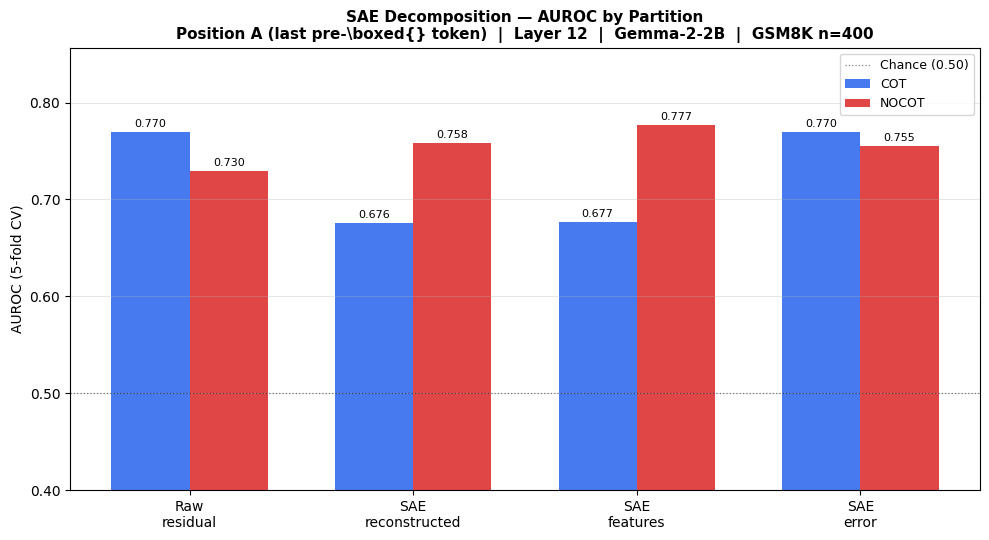

Saved: /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/figures/fig1_decomposition_bar_pos_a.png


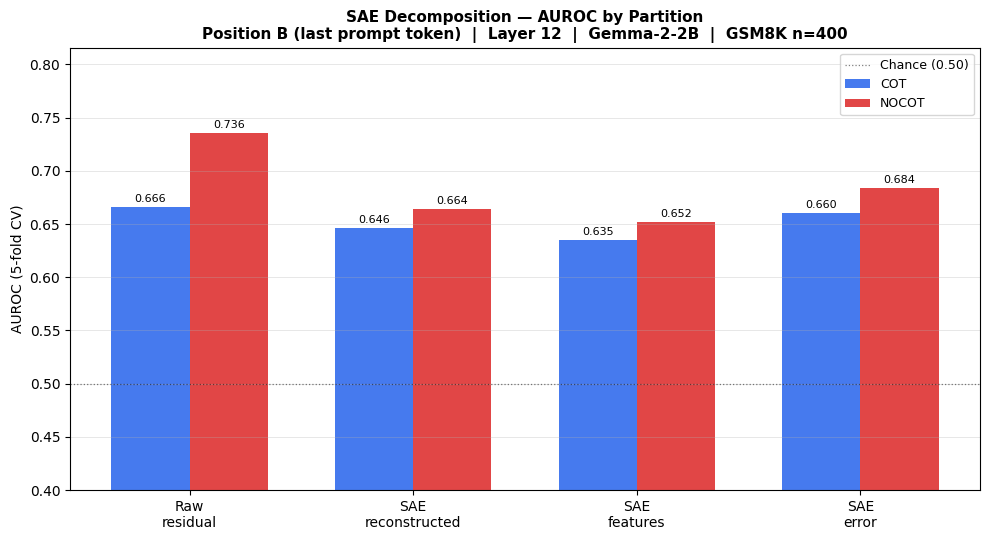

Saved: /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/figures/fig1_decomposition_bar_pos_b.png


In [ ]:
# Load df_lr from cache if not already in memory from §4f
if 'df_lr' not in dir():
    assert LR_FINAL_CSV.exists(), (
        f'LR results not found — run §4 first.\n{LR_FINAL_CSV}'
    )
    df_lr = pd.read_csv(LR_FINAL_CSV)
    print(f'Loaded {len(df_lr)} rows from {LR_FINAL_CSV.name}')

PART_ORDER  = ['raw', 'reconstructed', 'features', 'error']
PART_LABELS = {
    'raw':           'Raw\nresidual',
    'reconstructed': 'SAE\nreconstructed',
    'features':      'SAE\nfeatures',
    'error':         'SAE\nerror',
}
COND_COLORS = {'cot': '#2563EB', 'nocot': '#DC2626'}


def plot_decomposition_bar(df: pd.DataFrame, pos: str, save_path: Path) -> None:
    """Grouped bar chart of AUROC per partition for CoT and NoCoT at a given position."""
    sub   = df[df['position'] == pos].copy()
    pivot = (
        sub.pivot(index='partition', columns='condition', values='auroc')
           .reindex(PART_ORDER)
    )

    x, width = np.arange(len(PART_ORDER)), 0.35
    fig, ax  = plt.subplots(figsize=(10, 5.5))

    for i, cond in enumerate(('cot', 'nocot')):
        vals = pivot.get(cond, pd.Series(np.nan, index=PART_ORDER)).values
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, vals, width,
                      label=cond.upper(), color=COND_COLORS[cond], alpha=0.85)
        # Value labels inside each bar
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8,
                )

    ax.axhline(0.50, color='black', linestyle=':', linewidth=0.9, alpha=0.5,
               label='Chance (0.50)')

    pos_label = (
        'Position A (last pre-\\boxed{} token)'
        if pos == 'pos_a' else
        'Position B (last prompt token)'
    )
    ax.set_title(
        f'SAE Decomposition — AUROC by Partition\n'
        f'{pos_label}  |  Layer {SAE_LAYER}  |  Gemma-2-2B  |  GSM8K n=400',
        fontsize=11, fontweight='bold',
    )
    ax.set_xticks(x)
    ax.set_xticklabels([PART_LABELS[p] for p in PART_ORDER], fontsize=10)
    ax.set_ylabel('AUROC (5-fold CV)', fontsize=10)
    ymax = min(pivot.values[~np.isnan(pivot.values)].max() + 0.08, 1.02)
    ax.set_ylim(0.40, ymax)
    ax.legend(fontsize=9, loc='upper right')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', alpha=0.3, linewidth=0.7)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved: {save_path}')


for pos in POSITIONS:
    plot_decomposition_bar(
        df_lr, pos,
        FIGURES_DIR / f'fig1_decomposition_bar_{pos}.png',
    )

## 7. Feature Importance Chart

Horizontal bar chart of the top 20 SAE features ranked by `|LR coefficient|`, annotated
with Neuronpedia descriptions. Green = positive coefficient (associated with correct
answers); red = negative (associated with incorrect answers).

Saved to `figures/fig2_top_features_cot_pos_a.png`.

Saved: /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/figures/fig2_top_features_cot_pos_a.png


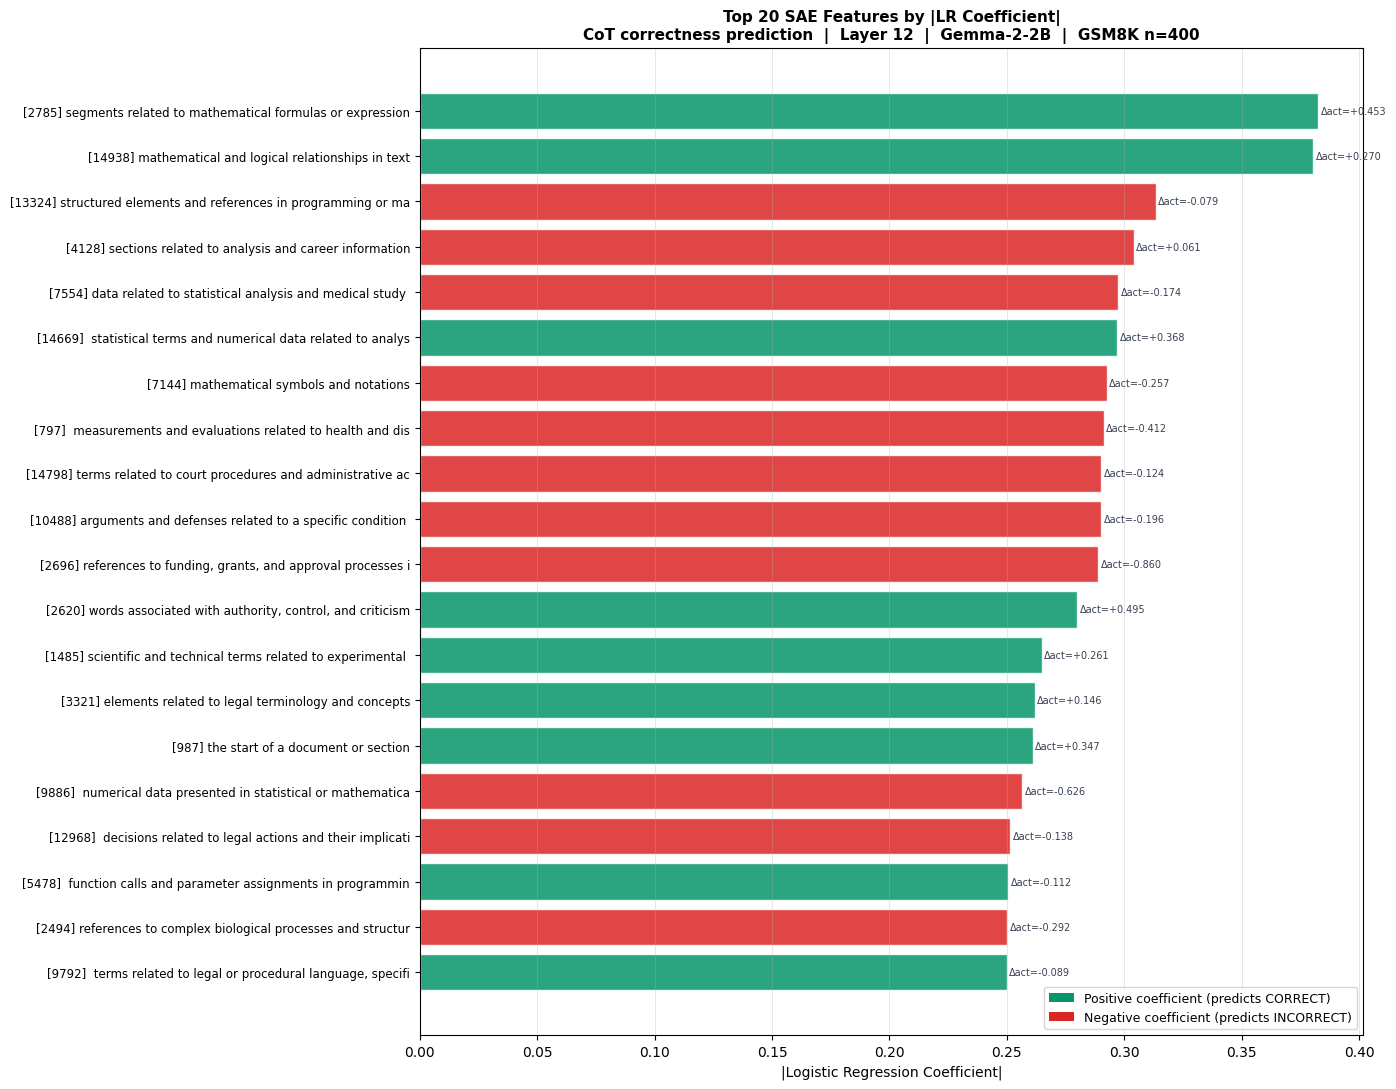

In [ ]:
# Load primary_top from cache if not already in memory from §5
_ann_csv = CACHE_DIR / 'top_features_cot_pos_a_annotated.csv'
if 'primary_top' not in dir():
    assert _ann_csv.exists(), (
        f'Top features not found — run §5 first.\n{_ann_csv}'
    )
    primary_top = pd.read_csv(_ann_csv)
    print(f'Loaded {len(primary_top)} top features from cache.')


def plot_top_features(
    top_df: pd.DataFrame, n_show: int = 20, save_path: Path = None,
) -> None:
    """Horizontal bar chart of top SAE features by |LR coef|, colored by direction."""
    df = top_df.head(n_show).copy()

    # Truncate long descriptions for readability
    df['label'] = df.apply(
        lambda r: f"[{int(r['feature_id'])}] {str(r.get('description', ''))[:55]}",
        axis=1,
    )

    colors  = ['#059669' if c > 0 else '#DC2626' for c in df['coef']]
    y_pos   = list(range(len(df) - 1, -1, -1))  # top feature at top of chart

    fig_h = max(0.45 * n_show + 2, 6)
    fig, ax = plt.subplots(figsize=(14, fig_h))

    ax.barh(y_pos, df['abs_coef'].values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['label'].values, fontsize=8.5)
    ax.set_xlabel('|Logistic Regression Coefficient|', fontsize=10)
    ax.set_title(
        f'Top {n_show} SAE Features by |LR Coefficient|\n'
        f'CoT correctness prediction  |  Layer {SAE_LAYER}  |  Gemma-2-2B  |  GSM8K n=400',
        fontsize=11, fontweight='bold',
    )

    legend_elements = [
        Patch(facecolor='#059669', label='Positive coefficient (predicts CORRECT)'),
        Patch(facecolor='#DC2626', label='Negative coefficient (predicts INCORRECT)'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.3, linewidth=0.7)

    # Annotate each bar with activation rate difference
    for i, (y, row) in enumerate(zip(y_pos, df.itertuples())):
        delta_str = f'Δact={row.delta_mean_act:+.3f}'
        ax.text(row.abs_coef + 0.001, y, delta_str,
                va='center', ha='left', fontsize=7, color='#374151')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()
    plt.close(fig)


plot_top_features(
    primary_top,
    n_show=20,
    save_path=FIGURES_DIR / 'fig2_top_features_cot_pos_a.png',
)

## 8. Feature Activation Distribution

Box plots comparing the activation magnitude of the top 10 features between
correct and incorrect CoT responses. Helps distinguish high-mean from
high-variance features — both matter, but through different mechanisms.

Saved to `figures/fig3_feature_distributions.png`.

Saved: /content/drive/MyDrive/experiments/exp2_sae_decomposition/backup/figures/fig3_feature_distributions.png


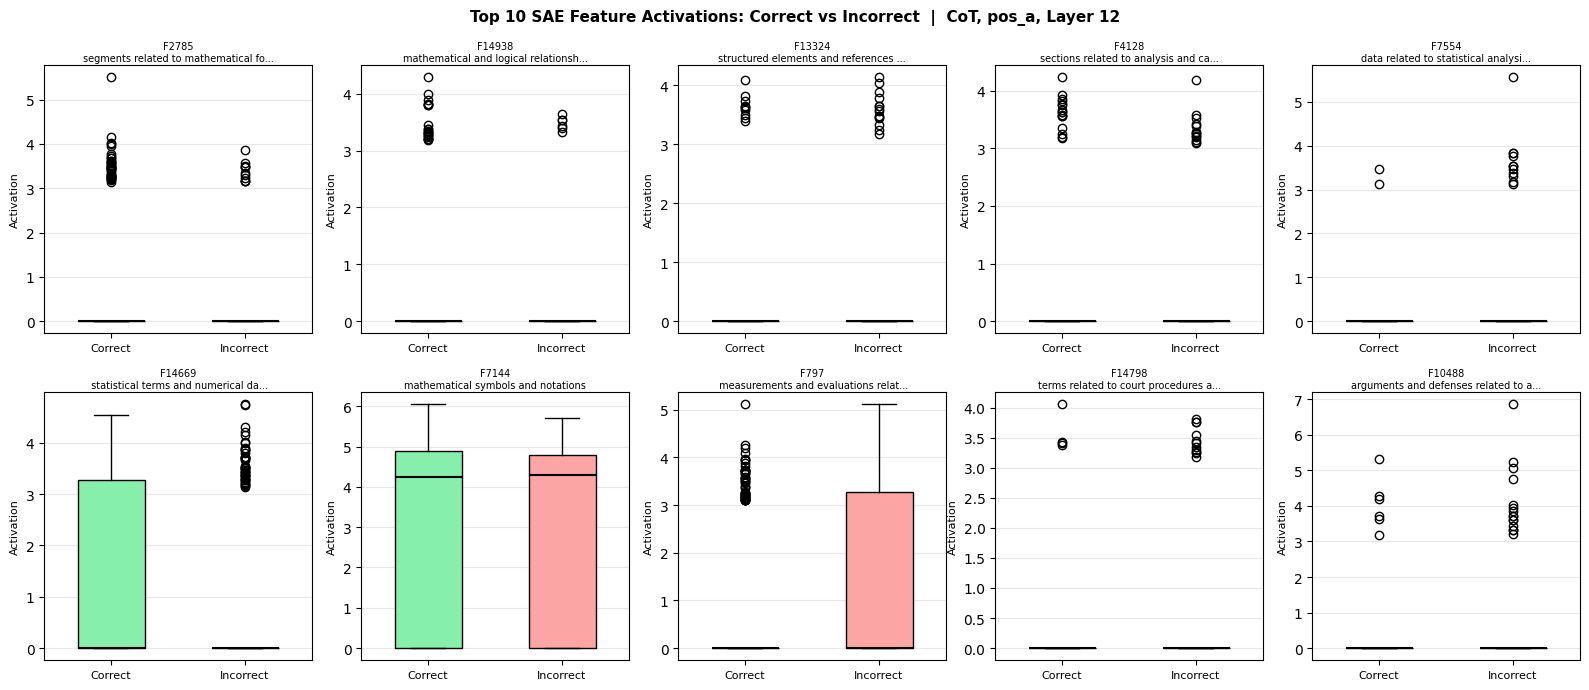

In [ ]:
# Load primary_top from cache if not already in memory from §5
_ann_csv = CACHE_DIR / 'top_features_cot_pos_a_annotated.csv'
if 'primary_top' not in dir():
    assert _ann_csv.exists(), (
        f'Top features not found — run §5 first.\n{_ann_csv}'
    )
    primary_top = pd.read_csv(_ann_csv)
    print(f'Loaded {len(primary_top)} top features from cache.')


def plot_feature_distributions(
    top_df: pd.DataFrame, n_top: int = 10, save_path: Path = None,
) -> None:
    """
    For the top n_top features, compare activation distributions between
    correct (green) and incorrect (red) CoT responses via box plots.
    """
    top_n   = top_df.head(n_top)
    fids    = top_n['feature_id'].values
    X       = decomp[('cot', 'pos_a')]['features']
    correct = y_cot.astype(bool)

    fig, axes = plt.subplots(2, 5, figsize=(16, 7), sharey=False)
    axes = axes.flatten()

    for ax, (fid, row) in zip(axes, zip(fids, top_n.itertuples())):
        act = X[:, int(fid)]
        data_correct   = act[correct]
        data_incorrect = act[~correct]

        bp = ax.boxplot(
            [data_correct, data_incorrect],
            patch_artist=True,
            widths=0.5,
            medianprops=dict(color='black', linewidth=1.5),
        )
        bp['boxes'][0].set_facecolor('#86EFAC')  # light green — correct
        bp['boxes'][1].set_facecolor('#FCA5A5')  # light red   — incorrect

        desc = (str(row.description)
                if hasattr(row, 'description') and not pd.isna(row.description)
                else '')
        short_desc = desc[:35] + '...' if len(desc) > 35 else desc
        ax.set_title(f'F{int(fid)}\n{short_desc}', fontsize=7, pad=3)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Correct', 'Incorrect'], fontsize=8)
        ax.set_ylabel('Activation', fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    fig.suptitle(
        f'Top {n_top} SAE Feature Activations: Correct vs Incorrect  |  '
        f'CoT, pos_a, Layer {SAE_LAYER}',
        fontsize=11, fontweight='bold',
    )
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()
    plt.close(fig)


plot_feature_distributions(
    primary_top,
    n_top=10,
    save_path=FIGURES_DIR / 'fig3_feature_distributions.png',
)

## Results

### Key Numbers

| Metric | CoT pos_a | NoCoT pos_a | CoT pos_b | NoCoT pos_b |
|---|---|---|---|---|
| **AUROC — raw residual** | **0.7695** | 0.7298 | 0.6660 | 0.7357 |
| AUROC — SAE reconstructed | 0.6756 | 0.7581 | 0.6464 | 0.6638 |
| AUROC — SAE features (16k) | 0.6772 | **0.7767** | 0.6346 | 0.6517 |
| **AUROC — SAE error** | **0.7698** | 0.7549 | **0.6601** | **0.6840** |
| SAE variance explained (R²) | 0.014 | — | — | — |
| Feature sparsity (% zero) | 99.4% | 99.3% | — | 99.4% |

**Dataset:** n = 400 · CoT accuracy = 51.0% (204/400) · NoCoT accuracy = 8.0% (32/400) · Flipped (CoT=✓, NoCoT=✗) = 186/400

---

### Top Features — CoT, pos_a (last pre-answer token)

| Rank | Feature | Coef | Dir | % active (correct) | % active (incorrect) | Δ mean act | Neuronpedia description |
|---|---|---|---|---|---|---|---|
| 1 | F2785 | +0.383 | ✓ | 18.1% | 5.6% | +0.453 | segments related to mathematical formulas or expressions |
| 2 | F14938 | +0.381 | ✓ | 10.8% | 3.1% | +0.270 | mathematical and logical relationships in text |
| 3 | F13324 | −0.313 | ✗ | 4.9% | 7.1% | −0.079 | structured elements in programming or mathematical contexts |
| 4 | F14669 | +0.297 | ✓ | 32.4% | 21.9% | +0.369 | statistical terms and numerical data related to analysis |
| 5 | F7144 | −0.293 | ✗ | 63.7% | 70.4% | −0.257 | mathematical symbols and notations *(paradox: more active in incorrect)* |
| 6 | F797 | −0.291 | ✗ | 23.0% | 34.7% | −0.412 | measurements related to health and disease conditions |
| 7 | F2696 | −0.289 | ✗ | 20.1% | 40.3% | −0.860 | references to funding and grants in research documents |
| 8 | F1485 | +0.265 | ✓ | 11.3% | 4.1% | +0.261 | scientific and technical terms related to experimental results |

*(✓ = associated with correct answers · ✗ = associated with incorrect answers · full top-20 in `cache/top_features_cot_pos_a_annotated.csv`)*

---

### Interpretation

**The correctness signal in CoT activations lives in the SAE error term, not the interpretable features.**

The headline result is that *error* AUROC (0.7698) is virtually identical to *raw* AUROC (0.7695) for CoT pos_a — the two are statistically indistinguishable. By contrast, both *features* AUROC (0.6772) and *reconstructed* AUROC (0.6756) drop by roughly −0.09 relative to the raw baseline. This means whatever residual-stream geometry distinguishes correct from incorrect CoT chains at layer 12 lives almost entirely in the subspace that the Gemma Scope dictionary does **not** span.

The SAE R² of **1.4%** corroborates this directly: the SAE reconstructs almost none of the problem-to-problem variance in these reasoning-phase activations. The SAE was trained on diverse pre-training text, and the step-by-step computation patterns during GSM8K generation appear to occupy a narrow domain-specific subspace outside the dictionary's vocabulary.

**NoCoT is a partial exception.** For NoCoT pos_a, features AUROC (0.7767) slightly *exceeds* the raw AUROC (0.7298) — the only condition where sparse interpretable features outperform the full residual. NoCoT "correctness" is likely driven by simpler, more stereotyped patterns (factual recall) that map cleanly onto dictionary atoms, whereas CoT correctness depends on dynamic computation the static SAE vocabulary does not capture.

**Top feature quality is mixed.** The two strongest positive predictors (F2785, F14938) carry interpretable math-related descriptions and are meaningfully more active in correct chains (18% vs 6%, 11% vs 3%), providing real mechanistic signal. However, most discriminative features — F7554 (medical statistics), F797 (health measurements), F14798 (court procedures), F2696 (research funding) — have descriptions entirely unrelated to mathematical reasoning, suggesting the high-dimensional sparse LR is finding coincidental correlations. Notably, F7144 ("mathematical symbols and notations") is *paradoxically more active in incorrect chains* (70% vs 64%), consistent with the model encoding active-but-failing computation.

**Position A vs B.** pos_a (last pre-answer token) outperforms pos_b (last prompt token) by 0.03–0.05 AUROC across all partitions, confirming that correctness-relevant information accumulates *during* the chain rather than before generation begins.

---

### Key Questions Answered

| Question | Answer |
|---|---|
| Does `AUROC_features ≈ AUROC_raw`? | **No.** Features lose ~0.09 AUROC vs raw for CoT (0.677 vs 0.770). |
| Is `AUROC_error ≈ 0.50`? | **No.** Error AUROC = 0.770 — nearly identical to raw. The signal is almost entirely *outside* the SAE-covered subspace. |
| Do top features relate to math/reasoning? | **Partially.** Top-2 features are math-relevant; most discriminative features are semantically off-domain. |
| Is CoT correctness interpretable via SAE? | **Mostly no.** NoCoT is marginally more interpretable than CoT. |

---

### Implications for Subsequent Experiments

- **Exp 4 (Flipped-Problems Classifier):** Error AUROC ≈ raw AUROC pattern likely holds; use raw residuals (not SAE features) for the causal classifier.
- **H1 Causal Mediation:** That ablating top-10 features collapses CoT accuracy (H1 result) is *not* contradicted here — those features may gate a mode-switch even if they don't carry the full correctness-discriminating signal. The two effects may be orthogonal.
- **Future SAE work:** An SAE trained on MATH/reasoning traces would be a stronger test of whether the correctness signal is truly uninterpretable, or merely outside Gemma Scope's vocabulary.

---

### Output Files

| File | Status |
|---|---|
| `cache/decomp_{cond}_{pos}_{part}.npy` (×12) | ✓ Saved in §3 |
| `cache/lr_fast_all.csv` | ✓ Saved in §4a |
| `cache/lr_features_{cond}_{pos}.csv` (×4) | ✓ Saved in §4b–4e |
| `cache/decomp_lr_results.csv` | ✓ Saved in §4f |
| `cache/top_features_{cond}_{pos}.csv` (×4) | ✓ Saved in §5 |
| `cache/top_features_cot_pos_a_annotated.csv` | ✓ Saved in §5 |
| `cache/neuronpedia_descriptions.json` | ✓ Saved in §5 |
| `figures/fig1_decomposition_bar_{pos}.png` (×2) | ✓ Saved in §6 |
| `figures/fig2_top_features_cot_pos_a.png` | ✓ Saved in §7 |
| `figures/fig3_feature_distributions.png` | ✓ Saved in §8 |
